<a href="https://colab.research.google.com/github/yelenana/machine_learning/blob/main/Rybchynska_Olena_%22HW_NLP_Classification_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
import os
path = '/content/drive/MyDrive/ML/4_1'
sys.path.append(path)

In [3]:
!ls drive/MyDrive/ML/4_1/

train.csv  tweet_sentiment_train.csv.zip


In [4]:
import pandas as pd
import numpy as np

In [5]:

raw_df = pd.read_csv("drive/MyDrive/ML/4_1/train.csv")
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [7]:
raw_df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [8]:
raw_df[raw_df.isnull().any(axis=1)]

,textID,text,selected_text,sentiment
314,fdb77c3752,NaN,NaN,neutral


In [9]:
df = raw_df.dropna().reset_index(drop=True)
print(f"до видалення: {raw_df.shape}")
print(f"після видалення: {df.shape}")

до видалення: (27481, 4)
після видалення: (27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [10]:
class_counts = df['sentiment'].value_counts()
class_props = df['sentiment'].value_counts(normalize=True)
print(class_counts)
print(class_props.round(3))

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64
sentiment
neutral     0.405
positive    0.312
negative    0.283
Name: proportion, dtype: float64


Класи не ідеально збалансовані, але різниця між найбільшим і найменшим класом приблизно 12%, що не виглядає критичним.
Через дисбаланс класів самої accuracy буде недостатньо для оцінки якості — варто дивитись і на f1-score (macro), який однаково враховує всі три класи, незалежно від їх розміру.

In [11]:
df['text_len'] = df['text'].str.len()
df['text_len'].describe()

,text_len
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

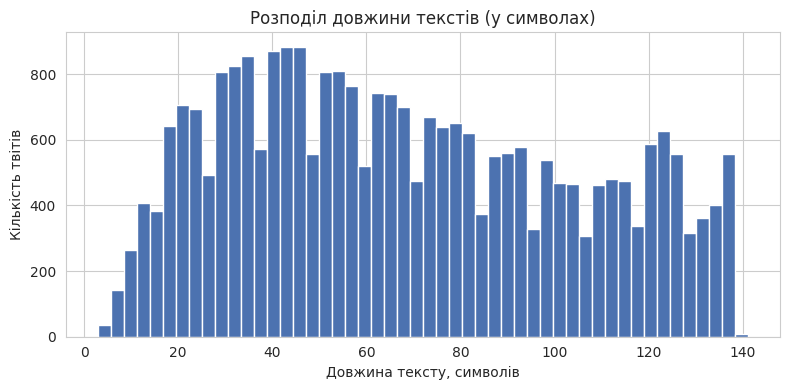

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
df['text_len'].hist(bins=50, ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Розподіл довжини текстів (у символах)')
ax.set_xlabel('Довжина тексту, символів')
ax.set_ylabel('Кількість твітів')
plt.tight_layout()
plt.show()

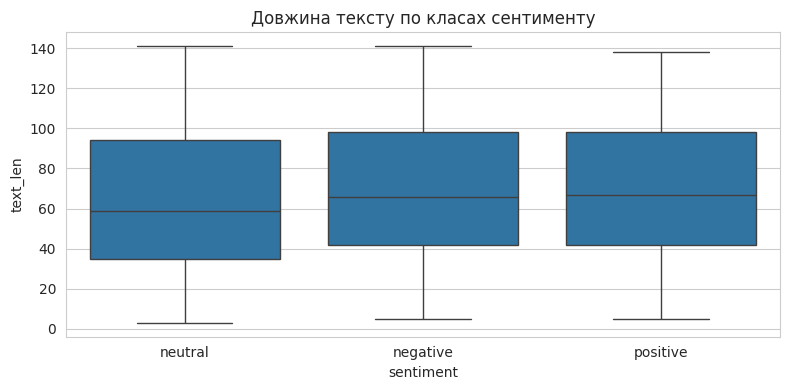

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='sentiment', y='text_len', ax=ax)
ax.set_title('Довжина тексту по класах сентименту')
plt.tight_layout()
plt.show()

Довжина текстів обмежена 141 символом — типовий ліміт довжини твіту (Twitter/X).

 - Розподіл
  немонотонний: основний пік припадає на короткі тексти (~30-50 символів), є другий менший пік
  ближче до максимальної довжини (твіти, що майже впираються в ліміт), і різкий обрив на 141
  символі — ознака штучного технічного обмеження, а не природного хвоста розподілу.
  
- Довжина тексту практично не залежить від класу сентименту (медіани та IQR по `positive`,
  `negative`, `neutral` майже однакові) — отже, довжина не є корисною ознакою для класифікації,
  і фокусуватись треба на змісті/лексиці тексту.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [15]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

english_stopwords = set(stopwords.words('english'))
stemmer = SnowballStemmer(language='english')

print(f"Кількість стоп-слів: {len(english_stopwords)}")

Кількість стоп-слів: 198


In [17]:
english_stopwords = stopwords.words('english')
stemmer = SnowballStemmer(language='english')

def tokenize(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    return [stemmer.stem(word) for word in tokens]

In [18]:
sample = df['text'].iloc[1]
print("До обробки: ", sample)
print("Після обробки:", tokenize(sample))

До обробки:   Sooo SAD I will miss you here in San Diego!!!
Після обробки: ['sooo', 'sad', 'i', 'will', 'miss', 'you', 'here', 'in', 'san', 'diego']


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=1000  # поки що довільне число — підберемо усвідомлено далі
)

vectorizer.fit(df['text'])
print(len(vectorizer.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


1000


In [20]:
probe_vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords
)
X_probe = probe_vectorizer.fit_transform(df['text'])
print(f"Розмір повного словника: {len(probe_vectorizer.vocabulary_)} унікальних токенів")

Розмір повного словника: 17766 унікальних токенів


In [21]:
import numpy as np

freqs = np.asarray(X_probe.sum(axis=0)).ravel()
order = np.argsort(freqs)[::-1]
cum_share = np.cumsum(freqs[order]) / freqs.sum()

for target in [0.80, 0.90, 0.95, 0.98]:
    n_words = np.searchsorted(cum_share, target) + 1
    print(f"{int(target*100)}% усіх входжень слів покриваються {n_words} найчастотнішими токенами")

80% усіх входжень слів покриваються 1525 найчастотнішими токенами
90% усіх входжень слів покриваються 4046 найчастотнішими токенами
95% усіх входжень слів покриваються 8277 найчастотнішими токенами
98% усіх входжень слів покриваються 13971 найчастотнішими токенами


In [22]:
feature_names = probe_vectorizer.get_feature_names_out()
top_n = 30
top_tokens = [feature_names[i] for i in order[:top_n]]
print(top_tokens)

['day', 'go', 'get', 'good', 'work', 'love', 'like', 'got', 'http', 'today', 'time', 'one', 'lol', 'happi', 'want', 'thank', 'know', 'miss', 'u', 'realli', 'back', 'see', 'think', 'feel', 'im', 'night', 'hope', 'mother', 'make', 'new']


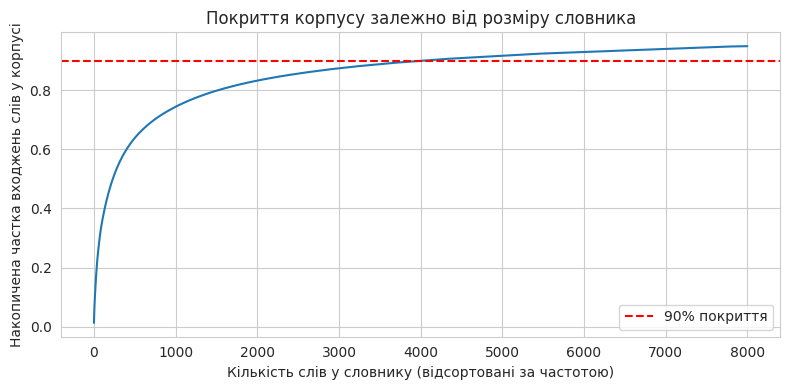

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cum_share[:8000])
ax.axhline(0.9, color='red', linestyle='--', label='90% покриття')
ax.set_xlabel('Кількість слів у словнику (відсортовані за частотою)')
ax.set_ylabel('Накопичена частка входжень слів у корпусі')
ax.set_title('Покриття корпусу залежно від розміру словника')
ax.legend()
plt.tight_layout()
plt.show()

Розмір словника для `CountVectorizer` обрано на основі аналізу покриття корпусу (крива Zipf):
  90% усіх слововживань покриваються ~4000 найчастотніших токенів, після чого крива виходить
  на плато — додавання тисяч рідкісних слів дає мізерний приріст покриття. Тому обрано
  `max_features=4000` як компроміс між повнотою словника і розмірністю ознак.

In [24]:
bow_vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=4000
)

X_bow_full = bow_vectorizer.fit_transform(df['text'])
print("Розмір матриці Bag-of-Words:", X_bow_full.shape)

Розмір матриці Bag-of-Words: (27480, 4000)


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [25]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']   # зберігаємо пропорції класів в train і test
)

X_train_bow = X_bow_full[train_idx]
X_test_bow = X_bow_full[test_idx]
y_train = df.loc[train_idx, 'sentiment']
y_test = df.loc[test_idx, 'sentiment']

X_train_bow.shape, X_test_bow.shape

((21984, 4000), (5496, 4000))

Спочатку навчимо логістичну регресію

In [26]:
from sklearn.linear_model import LogisticRegression

MAX_ITER = 1000

model = LogisticRegression(max_iter=MAX_ITER, solver='sag')

In [27]:
%%time
model.fit(X_train_bow, y_train)

CPU times: user 1.5 s, sys: 6.43 ms, total: 1.51 s
Wall time: 1.54 s


LogisticRegression(max_iter=1000, solver='sag')

In [28]:
train_preds = model.predict(X_train_bow)
train_preds

array(['neutral', 'negative', 'neutral', ..., 'neutral', 'neutral',
       'neutral'], dtype=object)

In [29]:
pd.Series(train_preds).value_counts()

,count
neutral,9872
positive,6587
negative,5525


In [30]:
pd.Series(y_train).value_counts()

,count
sentiment,
neutral,8894
positive,6865
negative,6225


Якщо порівняти прогнозні значення (train_preds) та реальні (y_train), то побачимо що модель має невеликий "перекіс" у бік класу neutral — вона передбачає його частіше, ніж він насправді зустрічається, і натомість недопередбачає negative найбільше з усіх трьох класів. Це узгоджується з результатами EDA: нейтральні твіти найчастіше "плутаються" з емоційно забарвленими

In [31]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_score(y_train, train_preds)

0.8057223435225619

In [32]:
f1_score(y_train, train_preds, average='macro')

0.8057702767958542

In [33]:
test_preds = model.predict(X_test_bow)

In [34]:
accuracy_score(y_test, test_preds)

0.6901382823871907

In [35]:
f1_score(y_test, test_preds, average='macro')

0.6916333053153059

Test accuracy та f1_macro майже ідентичні (0.690 vs 0.692) — це означає, що модель не має явного перекосу в бік якогось одного класу на тестових даних, і accuracy тут не вводить в оману попри незбалансованість класів.

Порівняємо з примітивною моделлю

In [36]:
import numpy as np

baseline_preds = np.full(len(y_test), 'neutral')

accuracy_score(y_test, baseline_preds)

0.4044759825327511

In [37]:
f1_score(y_test, baseline_preds, average='macro')

0.1919937815779246

Висновок: baseline-модель дає непогану на перший погляд accuracy (40%), але її f1_macro низький (0.19) — саме тому, що вона повністю ігнорує класи positive і negative (для них precision/recall/f1 = 0, оскільки вона їх ніколи не передбачає). LogisticRegression на BoW дає суттєвий і змістовний приріст над обома метриками — це підтверджує, що модель дійсно навчилась розрізняти сентимент, а не просто користується дисбалансом класів

Пробуємо ще інші моделі:DecisionTreeClassifier і MultinomialNB

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

In [39]:
tree_model = DecisionTreeClassifier(max_depth=30, random_state=42)
tree_model.fit(X_train_bow, y_train)

tree_preds = tree_model.predict(X_test_bow)
print("DecisionTree  accuracy:", accuracy_score(y_test, tree_preds))
print("DecisionTree  f1_macro:", f1_score(y_test, tree_preds, average='macro'))

DecisionTree  accuracy: 0.6404657933042213
DecisionTree  f1_macro: 0.6210248062268731


In [40]:
%%time
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

nb_preds = nb_model.predict(X_test_bow)
print("MultinomialNB accuracy:", accuracy_score(y_test, nb_preds))
print("MultinomialNB f1_macro:", f1_score(y_test, nb_preds, average='macro'))

MultinomialNB accuracy: 0.6541120815138283
MultinomialNB f1_macro: 0.6567907359250096
CPU times: user 130 ms, sys: 980 µs, total: 131 ms
Wall time: 137 ms


In [41]:
comparison = pd.DataFrame({
    "LogisticRegression": {"accuracy": accuracy_score(y_test, test_preds),
                            "f1_macro": f1_score(y_test, test_preds, average='macro')},
    "DecisionTree":       {"accuracy": accuracy_score(y_test, tree_preds),
                            "f1_macro": f1_score(y_test, tree_preds, average='macro')},
    "MultinomialNB":      {"accuracy": accuracy_score(y_test, nb_preds),
                            "f1_macro": f1_score(y_test, nb_preds, average='macro')},
}).T

comparison

,accuracy,f1_macro
LogisticRegression,0.690138,0.691633
DecisionTree,0.640466,0.621025
MultinomialNB,0.654112,0.656791


Висновок: LogisticRegression — найкраща модель серед випробуваних, з відривом ~4-5 п.п. від конкурентів за обома метриками.
Обираємо LogisticRegression як фінальну модель для BoW (accuracy 0.690, f1_macro 0.692)

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

    negative       0.70      0.63      0.67      1556
     neutral       0.63      0.72      0.67      2223
    positive       0.77      0.70      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.69      0.69      5496
weighted avg       0.70      0.69      0.69      5496



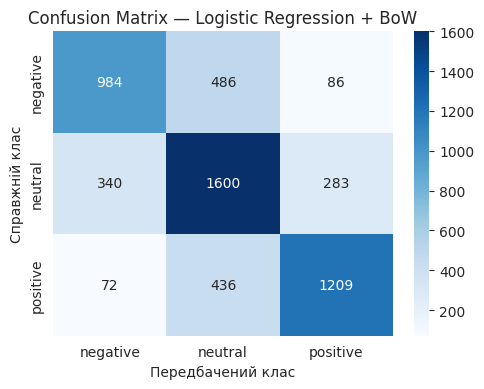

In [43]:
cm = confusion_matrix(y_test, test_preds, labels=model.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)
ax.set_xlabel('Передбачений клас')
ax.set_ylabel('Справжній клас')
ax.set_title('Confusion Matrix — Logistic Regression + BoW')
plt.tight_layout()
plt.show()

**Висновки до Завдання 4:**

- Дані розбито на train/test (80%/20%) зі стратифікацією за `sentiment`, щоб зберегти пропорції
  класів в обох вибірках.
- Порівняно три класифікатори на BoW-векторах: LogisticRegression (accuracy 0.690, f1_macro 0.692),
  DecisionTree (0.640 / 0.621) та MultinomialNB (0.654 / 0.657). LogisticRegression показала
  найкращий результат і обрана як фінальна модель.
- Модель суттєво перевершує baseline ("завжди neutral"): accuracy +28.6 п.п. (0.690 проти 0.404),
  а f1_macro — аж +50 п.п. (0.692 проти 0.192), що підтверджує: модель дійсно навчилась
  розрізняти сентимент, а не користується дисбалансом класів.
- З confusion matrix видно логічну структуру помилок: модель майже не плутає протилежні класи
  (`negative` ↔ `positive`, лише ~3% помилок), основні складнощі — відрізнити слабко виражений
  сентимент від `neutral` (це і логічно, і узгоджується з EDA).
- Виявлено ознаку перенавчання: train-метрики (0.81) помітно вищі за test-метрики (0.69) —
  простір для регуляризації/тюнінгу в майбутньому.
- **Загальна оцінка:** якість класифікації помірно хороша — значно краще за тривіальний baseline,
  але не ідеальна; є потенціал для покращення (детальніше — у Завданні 7).

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [44]:
model.coef_.shape

(3, 4000)

In [45]:
model.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [46]:
feature_names_bow = bow_vectorizer.get_feature_names_out()

for i, cls in enumerate(model.classes_):
    coefs = pd.Series(model.coef_[i], index=feature_names_bow, name='imp').sort_values(ascending=False)
    print(f"=== Клас: {cls} ===")
    print("Топ-10 слів, що ЗБІЛЬШУЮТЬ ймовірність цього класу:")
    print(coefs[:10])
    print()
    print("Топ-10 слів, що ЗМЕНШУЮТЬ ймовірність цього класу:")
    print(coefs[-10:])
    print("\n")

=== Клас: negative ===
Топ-10 слів, що ЗБІЛЬШУЮТЬ ймовірність цього класу:
sad        2.670047
suck       2.467307
sorri      2.418675
bore       2.331498
hate       2.280781
fail       2.148744
stupid     2.131832
miss       2.088751
exhaust    2.056746
worst      2.045799
Name: imp, dtype: float64

Топ-10 слів, що ЗМЕНШУЮТЬ ймовірність цього класу:
congrat   -1.546813
enjoy     -1.625625
amaz      -1.638391
welcom    -1.768262
cute      -1.838262
thank     -2.026211
beauti    -2.045077
love      -2.173487
glad      -2.274560
awesom    -2.390124
Name: imp, dtype: float64


=== Клас: neutral ===
Топ-10 слів, що ЗБІЛЬШУЮТЬ ймовірність цього класу:
indoor         1.549385
otherwis       1.339358
oooo           1.234589
colorado       1.199636
starwarsday    1.184837
satisfi        1.106488
jst            1.100353
depot          1.077665
pfft           1.040860
england        1.035071
Name: imp, dtype: float64

Топ-10 слів, що ЗМЕНШУЮТЬ ймовірність цього класу:
delici      -1.129158
truli

Виснвоок:

Для negative і positive все логічно - модель сама "вивчила" емоційні слова.
Negative: sad, suck, sorri, bore, hate, stupid, worst.
Positive: awesom, cute, thank, love, glad, nice, excit.
І що цікаво - слова, які знижують ймовірність одного класу, це часто ті самі слова, що
підвищують ймовірність протилежного (наприклад "sad" підвищує negative і знижує positive).
А от з neutral не так все зрозуміло. топ "позитивних" ознак для нього — не осмислена нейтральна лексика, а суміш рідкісних (`indoor`, `colorado`,
  `starwarsday`, `pfft`), тоді як слова, що знижують ймовірність neutral, — знову ж явно емоційна лексика (`thrill`, `incred`, `congratul`).

  На відміну від positive/negative, клас neutral не має власного характерного
  словника — він визначається радше відсутністю сильної емоційної лексики, ніж наявністю
  специфічних "нейтральних" слів.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=4000
)

X_tfidf_full = tfidf_vectorizer.fit_transform(df['text'])
print("Розмір матриці TF-IDF:", X_tfidf_full.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


Розмір матриці TF-IDF: (27480, 4000)


In [48]:
X_train_tfidf = X_tfidf_full[train_idx]
X_test_tfidf = X_tfidf_full[test_idx]
X_train_tfidf.shape, X_test_tfidf.shape

((21984, 4000), (5496, 4000))

Навчаємо модель LogisticRegression на TF-IDF-векторах

In [49]:
%%time
tfidf_model = LogisticRegression(max_iter=MAX_ITER, solver='sag')
tfidf_model.fit(X_train_tfidf, y_train)

CPU times: user 262 ms, sys: 1.98 ms, total: 264 ms
Wall time: 265 ms


LogisticRegression(max_iter=1000, solver='sag')

In [50]:
tfidf_test_preds = tfidf_model.predict(X_test_tfidf)

accuracy_score(y_test, tfidf_test_preds)

0.6895924308588064

In [51]:
f1_score(y_test, tfidf_test_preds, average='macro')

0.6899607254501207

In [52]:
comparison_vectorizers = pd.DataFrame({
    "BoW":    {"accuracy": accuracy_score(y_test, test_preds),
               "f1_macro": f1_score(y_test, test_preds, average='macro')},
    "TF-IDF": {"accuracy": accuracy_score(y_test, tfidf_test_preds),
               "f1_macro": f1_score(y_test, tfidf_test_preds, average='macro')},
}).T

comparison_vectorizers

,accuracy,f1_macro
BoW,0.690138,0.691633
TF-IDF,0.689592,0.689961


Різниця мінімальна, обидва підходи практично на одному рівні

Проведемо аналіз важливості слів

In [53]:
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

for i, cls in enumerate(tfidf_model.classes_):
    coefs = pd.Series(tfidf_model.coef_[i], index=feature_names_tfidf, name='imp').sort_values(ascending=False)
    print(f"=== Клас: {cls} (TF-IDF) ===")
    print("Топ-10 слів:", list(coefs[:10].index))
    print("Топ-10 'анти'-слів:", list(coefs[-10:].index))
    print()

=== Клас: negative (TF-IDF) ===
Топ-10 слів: ['sad', 'miss', 'sorri', 'hate', 'suck', 'bore', 'fail', 'stupid', 'hurt', 'poor']
Топ-10 'анти'-слів: ['cute', 'amaz', 'enjoy', 'nice', 'great', 'glad', 'hope', 'awesom', 'thank', 'love']

=== Клас: neutral (TF-IDF) ===
Топ-10 слів: ['indoor', 'guitar', 'except', 'differ', 'starwarsday', 'otherwis', 'jst', 'sent', 'colorado', 'goin']
Топ-10 'анти'-слів: ['amaz', 'wtf', 'thank', 'excit', 'nice', 'funni', 'fail', 'stupid', 'good', 'happi']

=== Клас: positive (TF-IDF) ===
Топ-10 слів: ['love', 'thank', 'awesom', 'great', 'happi', 'good', 'nice', 'hope', 'amaz', 'enjoy']
Топ-10 'анти'-слів: ['poor', 'sick', 'shame', 'hate', 'bore', 'tire', 'suck', 'sorri', 'miss', 'sad']



Порівняння топ-слів TF-IDF vs BoW:

negative: sad, miss, sorri, hate, suck, bore, stupid — практично той самий набір, що й у BoW.


positive: love, thank, awesom, great, happi, good, nice — теж майже ідентично.


neutral: знову indoor, starwarsday, colorado — та сама картина з випадковими/рідкісними словами, що і у BoW.

In [54]:
print(classification_report(y_test, tfidf_test_preds))

              precision    recall  f1-score   support

    negative       0.72      0.61      0.66      1556
     neutral       0.62      0.75      0.68      2223
    positive       0.78      0.68      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



Порівняємо 2 репорти між собою

In [55]:
from sklearn.metrics import classification_report

report_bow = classification_report(y_test, test_preds, output_dict=True)
report_tfidf = classification_report(y_test, tfidf_test_preds, output_dict=True)

classes = ['negative', 'neutral', 'positive']
metrics = ['precision', 'recall', 'f1-score']

comparison_table = pd.DataFrame(
    {
        (cls, 'BoW'): [report_bow[cls][m] for m in metrics]
        for cls in classes
    } | {
        (cls, 'TF-IDF'): [report_tfidf[cls][m] for m in metrics]
        for cls in classes
    },
    index=metrics
)

# впорядковуємо колонки так, щоб BoW і TF-IDF йшли поряд для кожного класу
comparison_table = comparison_table[[(cls, vec) for cls in classes for vec in ['BoW', 'TF-IDF']]]
comparison_table.round(2)

negative        neutral        positive       
               BoW TF-IDF     BoW TF-IDF      BoW TF-IDF
precision     0.70   0.72    0.63   0.62     0.77   0.78
recall        0.63   0.61    0.72   0.75     0.70   0.68
f1-score      0.67   0.66    0.67   0.68     0.73   0.73

Висновок до завдання 6:

Як бачимо, з TF-IDF якість моделі не стала кращою. Accuracy і f1_macro вийшли майже такими
самими, як і з BoW (навіть на соту частку нижчими), тобто на цьому наборі даних різниця
між векторизаціями виявилась незначущою.

Топ-слова також вийшли майже ідентичними до BoW: ті самі love/thank/awesom для positive,
sad/miss/hate для negative, і та сама плутанина з рідкісними словами для neutral. Це
пояснюється тим, що це ті самі найважливіші слова корпусу, лише з дещо іншими вагами.

Який векторизатор обрати для фінальної імплементації? Незважаючи на мінімальну різницю в
якості, я б обрала TF-IDF. Він враховує не лише кількість входжень слова в тексті, а й
те, наскільки це слово є рідкісним у всьому корпусі — тому теоретично він має краще
узагальнюватись на більшому або іншому наборі даних. При цьому обчислюється він практично
з тією ж швидкістю, що й BoW, тож додаткової "ціни" за перехід немає.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [56]:
error_df = df.loc[test_idx].copy()
error_df['prediction'] = tfidf_test_preds
error_df['is_error'] = error_df['sentiment'] != error_df['prediction']

print(f"Загальна кількість помилок: {error_df['is_error'].sum()} з {len(error_df)} ({error_df['is_error'].mean():.1%})")

Загальна кількість помилок: 1706 з 5496 (31.0%)


In [57]:
error_df[error_df['is_error']].groupby(['sentiment', 'prediction']).size().sort_values(ascending=False)

sentiment  prediction
negative   neutral       533
positive   neutral       479
neutral    negative      295
           positive      257
negative   positive       78
positive   negative       64
dtype: int64

In [58]:
pd.set_option('display.max_colwidth', 120)

error_df[(error_df.sentiment == 'negative') & (error_df.prediction == 'neutral')][['text', 'sentiment', 'prediction']].sample(8, random_state=1)

,text,sentiment,prediction
2709,"on my 42nd written ****.. i get less ideas every day, and every day",negative,neutral
3542,my bf had to go to her dads for the week end. i will have 2 full days of bordom.,negative,neutral
26847,is still waiting.,negative,neutral
24630,heheheheh... lol... I always figured he`d send them your way if he got any dupes... I felt bad not sending him stu...,negative,neutral
15913,"Last one month due to summer, strawberry is not availble in the Chennai markets!",negative,neutral
25779,Swollen face.....again,negative,neutral
19981,And it stopped raining. Fuckingtastic! ),negative,neutral
19384,Everyone on the eastcoast... the rain hates us let`s just all fly to Cali. LOL,negative,neutral


In [59]:
error_df[(error_df.sentiment == 'positive') & (error_df.prediction == 'neutral')][['text', 'sentiment', 'prediction']].sample(8, random_state=1)

,text,sentiment,prediction
13959,"Woot freaking hoo, tho Mad World isn`t doing well on the iTunes top #100 chart.",positive,neutral
13833,guessing... Ran 4 miles & gym? Superman you oxox,positive,neutral
24584,Want: Trip to Boston next month. Need: Addit`l motivation to save the $ to do so. Beloved daughter wants to go with...,positive,neutral
3809,"Just finishing shooting, can u believe it, but got the job done",positive,neutral
9465,"_Henrie hey david, you`re hot",positive,neutral
15142,Hmmm thinking about taking back that I feel better this morning - I think I spoke to early,positive,neutral
13688,"They actually use standard speaker wire between them too, with standard terminals, so no soldering involved or anyt...",positive,neutral
18148,Travel blog up and running! http://charlenedianetravels.blogspot.com Can`t wait to start filling it up with entries! ),positive,neutral


In [60]:
error_df[((error_df.sentiment == 'positive') & (error_df.prediction == 'negative')) |
         ((error_df.sentiment == 'negative') & (error_df.prediction == 'positive'))][['text', 'sentiment', 'prediction']].head(10)

,text,sentiment,prediction
17483,"Awww, *hugs* I wish I could help.",negative,positive
27219,I can`t believe you tweeted that. It was our special moment,negative,positive
8542,not ideal bank holiday conditions.. a little over cast and rainy but perfect for a lazy day with a dvd,negative,positive
8916,_Happy_EmoX lmao. Lucky! It`s 10 minutes on foot for me ewww..... School.lol. On the bus now.,negative,positive
24341,Dont worry man. You`ll see me just as much this week as you did last week.,positive,negative
27190,friday night is my fav night of the week but now I have to go to stupid dog training classes,positive,negative
956,"alas, I am moving (like where i`m moving too, but the actual moving, ugh) wish I could go too!",positive,negative
13827,"Getting some DMs asking where I fell off to the past few days I was sick, but am all better now. I appreciate the c...",positive,negative
18834,feeling like ****. hope its not swine flu or something,negative,positive
19647,"Oh, don`t spoil my fun, lol",negative,positive


In [61]:
error_df.groupby('is_error')['text_len'].describe()[['mean', '50%', 'std']]

,mean,50%,std
is_error,,,
False,64.620844,58.0,35.189335
True,76.195780,75.0,34.651280


Висновок

З аналізу видно кілька причин, чому модель помиляється:

- найбільше помилок - це коли модель плутає negative/positive з neutral, і найменше - коли плутає positive з negative напряму. Вважаю, що це добре, значить модель хоча б не плутає протилежні за змістом емоції)

- в текстах з прямою плутаниною positive/negative майже завжди є або заперечення (not ideal... but perfect, Dont worry, hope its not), або змішані сигнали - і позитивні, і негативні слова в одному тексті одночасно

- також бачимо сарказм/іронію (heheheh... I felt bad, Fuckingtastic!), сленг і вигуки (Woot, lmao, oxox), одруківки (bordom замість boredom), і випадки, де сентимент передається через контекст чи метафору, а не через окреме "маркерне" слово

- цікаво, що довші тексти частіше потрапляють у помилки (медіана 75 символів проти 58 у правильних) - ймовірно тому, що в довшому тексті вищий шанс зустріти слова з протилежним сентиментом, які "збивають" модель

3 шляхи покращення якості класифікації:

1. Додати біграми (ngram_range=(1,2)) або окремо обробляти заперечення - це б допомогло моделі
   бачити конструкції типу "not ideal", "dont worry", а не окремі слова "ideal" і "worry" без
   контексту.

2. Використати ембединги слів (Word2Vec, GloVe) або трансформерні моделі замість BoW/TF-IDF -
   вони враховують контекст і семантику, а не просто факт наявності слова, і краще б впорались
   із сарказмом, синонімами і рідкісними/сленговими словами.

3. Покращити препроцесинг під специфіку твітів - додати обробку емодзі та емотиконів (зараз
   isalpha() відкидає ")" яке насправді несе позитивний сигнал), обробку подовжених слів
   (sooo -> so), і спробувати сильнішу модель (градієнтний бустинг, SVM з підбором
   гіперпараметрів) замість простої логістичної регресії.